In [18]:
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import json
from pprint import pprint
import pandas as pd
import numpy as np

[6900 6800 6600 6301 5905 5417 4847 4212 3535 2837 2129 1420  710]
[6797 6697 6497 6198 5800 5311 4744 4121 3464 2783 2091 1394  697]
[6674 6574 6374 6076 5682 5199 4642 4029 3380 2713 2039 1360  680]
[139 137 133 127 119 109  97  84  70  56  42  28  14]
[139 137 133 127 119 109  97  84  70  56  42  28  14]
[133 131 127 121 113 103  91  78  65  52  39  26  13]


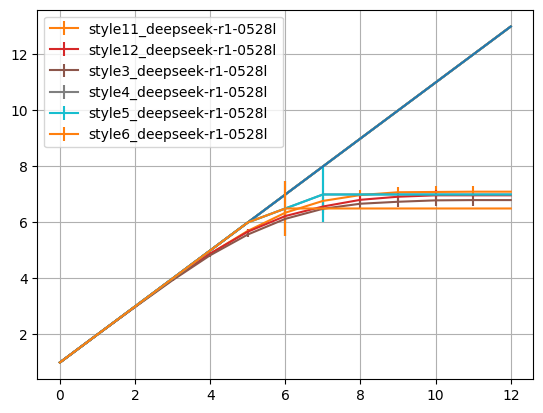

In [19]:
for file in [
    "../src/optimal_explorer/strategies/combination_lock/logs/llm_calls/style11_deepseek-r1-0528.jsonl",
    "../src/optimal_explorer/strategies/combination_lock/logs/llm_calls/style12_deepseek-r1-0528.jsonl",
    "../src/optimal_explorer/strategies/combination_lock/logs/llm_calls/style3_deepseek-r1-0528.jsonl",
    "../src/optimal_explorer/strategies/combination_lock/logs/llm_calls/style4_deepseek-r1-0528.jsonl",
    "../src/optimal_explorer/strategies/combination_lock/logs/llm_calls/style5_deepseek-r1-0528.jsonl",
    "../src/optimal_explorer/strategies/combination_lock/logs/llm_calls/style6_deepseek-r1-0528.jsonl",
]:
    lines = open(file, 'r').readlines()
    lines = [json.loads(line) for line in lines]
    df = pd.read_json(file, lines=True)
    df = df[~df['usage'].isna()]
    df['usage'].apply(lambda x: x['total_tokens'])
    df['total_tokens'] = df['usage'].apply(lambda x: x['total_tokens'])
    def std_err(x):
        return x.std() * 1.96 / np.sqrt(len(x))
    sum_stats = df.groupby("attempt").agg({"total_tokens": ['mean', std_err]})
    x = sum_stats['total_tokens']['mean'].index
    # plt.plot()
    df["guess"] = df['choices'].apply(lambda x: x[0]['message']['content'])
    # df.iloc[0].choices[0]["message"]['content']
    df['success'] = df['guess'] == df['target_combination']
    # we know there are 100 total target_combinations right? ohh only 96 for some reason..., well any ways, we calculate the regret curve from the number completed.
    # len(df['target_combination'].unique())
    # plt.scatter(df.attempt, df.success)
    # how do I construct the regret curve that satvik has been making? it should just make sense right?
    # the regret is the sum over time steps available in a horizon (optimal policy reward on this step - your policy.), hence linear regret for random policy makes sense? are you getting 1 reward for the optimal policy for every turn? this could make sense then sub optimal policies get 0 reward so long as they don't have the correct word.
    # so it looks like regret for step i is the regret at step i-1 plus the fraction which are not done at this step.

    optimal_regret = np.ones(13).cumsum()

    plt.plot(optimal_regret)
    alive_by_turn_i = []
    for i in range(1, 14):
        alive_by_turn_i.append(sum(df.attempt==i))
    alive_count = np.array(alive_by_turn_i).cumsum()
    fraction_alive_per_turn = (np.array(alive_by_turn_i) / alive_by_turn_i[0])
    regret = (fraction_alive_per_turn.cumsum()) # regret of 1 for being alive lol.
    # this std calc treats the termination probablilty at each step as a bernoulli where the examples were the remaining at that step to get the std of the mean.
    regret_yerr = 1.96 * (np.sqrt(((1-fraction_alive_per_turn) * fraction_alive_per_turn)) / np.sqrt(np.array(alive_by_turn_i) + 1e-6))
    print(alive_count[::-1].cumsum()[::-1])
    name = file.split("/")[-1].replace('.json', "")
    plt.errorbar(range(len(regret)), regret, yerr=regret_yerr, label=name)
plt.legend()
plt.grid()
plt.show()

In [21]:
fig = go.Figure()
# style = "3"
for style in ["11", "12", "3", "4", "5", "6"]:
    results_path: str = f'../src/optimal_explorer/strategies/combination_lock/logs/game_results/style{style}.jsonl'
    llm_call_path: str = f'../src/optimal_explorer/strategies/combination_lock/logs/llm_calls/style{style}_'
    bayes_optimal_path: str = f'../src/optimal_explorer/strategies/combination_lock/logs/bayes_optimal.jsonl'

    models = [
        # "Gemini Pro 2.5",
        "DeepSeek R1",
        # "Claude Opus 4",
        # "Claude 3.5 Sonnet",
        # "OpenAI o3",
    ]

    model_ids = [
        # "google/gemini-2.5-pro-preview",
        "deepseek/deepseek-r1-0528",
        # "anthropic/claude-opus-4",
        # "anthropic/claude-3.5-sonnet",
        # "openai/o3",
    ]

    llm_call_file_ids = [
        # "gemini-2.5-pro-preview",
        "deepseek-r1-0528",
        # "claude-opus-4",
        # "claude-3.5-sonnet",
        # "o3",
    ]
    tokens_used = []

    for i, model in enumerate(models):
        print(f"Processing {model}...")
        with open(f'{llm_call_path}{llm_call_file_ids[i]}.jsonl', 'r') as f:
            for line in f:
                data = json.loads(line)
                model_name = data['model']
                try:
                    
                    tokens = data['usage']['total_tokens']
                    if style == 6:
                        tokens += sum(d["usage"]['total_tokens'] for d in data['other_lm_calls'])
                except:
                    tokens = 0
                game_id = data['game_id']
                style_val = data['prompt_style']
                if int(style) > 2:
                    attempt = data['attempt']
                else:
                    user_prompt = data['user_prompt']
                    # number of times the word "Attempt" appears in the user prompt
                    attempt = user_prompt.count("Attempt")
                tokens_used.append({
                    'model': model_name,
                    'tokens': tokens,
                    'game_id': game_id,
                    'style': style_val,
                    'attempt': attempt
                })

    tokens_used_df = pd.DataFrame(tokens_used)
    display(tokens_used_df.head(2))
    tokens_model_attempt = []
    tokens_model_attempt_std_err = []
    def std_err(x): 
        return x.std() * 1.96 / np.sqrt(len(x))
    for i, model in enumerate(models):
        print(f"Processing {model}...")
        model_id = model_ids[i]
        games_df = tokens_used_df[ 
            (tokens_used_df['model'] == model_id) &
            (tokens_used_df['style'].astype(str) == style)
        ]
        tokens_stats_by_attempt = games_df[games_df['tokens'] != 0]\
            .groupby('attempt')['tokens'].agg(['mean', std_err]).reset_index()
        tokens_model_attempt.append(tokens_stats_by_attempt['mean'].tolist())
        tokens_model_attempt_std_err.append(tokens_stats_by_attempt['std_err'].tolist())



    colors = [px.colors.qualitative.Dark24[i] for i in np.array([1, 10, 6, 13, 16]) + int(style)%10-1]
    # Helper to convert hex color to rgba with alpha
    def hex_to_rgba(hex_color, alpha=0.2):
        hex_color = hex_color.lstrip('#')
        if len(hex_color) == 6:
            r, g, b = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))
        else:
            # fallback to black if color is not valid
            r, g, b = 0, 0, 0
        return f'rgba({r},{g},{b},{alpha})'

    for i, model in enumerate(models):
        x = list(range(len(tokens_model_attempt[i])))
        y = tokens_model_attempt[i]
        # Get standard deviation from variance, handle possible NaN
        std_err_temp = [v if v == v else 0 for v in tokens_model_attempt_std_err[i]]
        # std = [v**0.5 if v is not None and not pd.isna(v) else 0 for v in var]
        y_upper = [a + b for a, b in zip(y, std_err_temp)]
        y_lower = [a - b for a, b in zip(y, std_err_temp)]

        # Add shaded error band
        fig.add_trace(go.Scatter(
            x=x + x[::-1],
            y=y_upper + y_lower[::-1],
            fill='toself',
            fillcolor=hex_to_rgba(colors[i], 0.2),  # use rgba for transparency
            line=dict(color='rgba(255,255,255,0)'),
            hoverinfo="skip",
            showlegend=False,
            name=f"{model} error",
        ))

        # Add mean line
        fig.add_trace(go.Scatter(
            x=x,
            y=y,
            mode='lines+markers',
            name=model + f" s={style}",
            line=dict(color=colors[i], width=4),
            marker=dict(size=10),
        ))
    fig.update_layout(
        title='',
        xaxis_title='Episode',
        yaxis_title='Tokens Used (Total)',
        legend_title='Model',
        template='plotly_white',
        width=650,
        height=450,
    )
    display(fig)
    # break

Processing DeepSeek R1...


,model,tokens,game_id,style,attempt
0,deepseek/deepseek-r1-0528,339,5,11,1
1,deepseek/deepseek-r1-0528,339,58,11,1


Processing DeepSeek R1...


Processing DeepSeek R1...


,model,tokens,game_id,style,attempt
0,deepseek/deepseek-r1-0528,648,28,12,1
1,deepseek/deepseek-r1-0528,696,72,12,1


...

Processing DeepSeek R1...


,model,tokens,game_id,style,attempt
0,deepseek/deepseek-r1-0528,1675,1,6,1
1,deepseek/deepseek-r1-0528,3000,0,6,1


Processing DeepSeek R1...


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'fill': 'toself',
              'fillcolor': 'rgba(225,95,153,0.2)',
              'hoverinfo': 'skip',
              'line': {'color': 'rgba(255,255,255,0)'},
              'name': 'Gemini Pro 2.5 error',
              'showlegend': False,
              'type': 'scatter',
              'x': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 11, 10, 9, 8, 7, 6, 5,
                    4, 3, 2, 1, 0],
              'y': [871.7214819593472, 1324.5575278371919, 1615.6920347590828,
                    1467.5039428823775, 1741.3632179238975, 1271.877891327833,
                    1342.1013551836988, 1435.6051993698777, 1503.2683719219112,
                    1726.0293243707936, 2443.657625917822, 2578.488174104496,
                    1184.011825895504, 1295.231262971067, 965.2206756292064,
                    895.8085511550115, 845.01384824917, 852.7986448163012,
                    776.964213935325, 423.1256709649914, 678.0585571176224,
                    539.4998844328363, 373.3624721628083, 428.8985180406527]},
             {'line': {'color': '#E15F99', 'width': 4},
              'marker': {'size': 10},
              'mode': 'lines+markers',
              'name': 'Gemini Pro 2.5',
              'type': 'scatter',
              'x': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
              'y': [650.31, 848.96, 1077.5959595959596, 1072.78125,
                    1082.2444444444445, 1024.421052631579, 1097.45,
                    1140.3095238095239, 1199.5384615384614, 1345.625,
                    1869.4444444444443, 1881.25]},
             {'fill': 'toself',
              'fillcolor': 'rgba(0,160,139,0.2)',
              'hoverinfo': 'skip',
              'line': {'color': 'rgba(255,255,255,0)'},
              'name': 'DeepSeek R1 error',
              'showlegend': False,
              'type': 'scatter',
              'x': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 11, 10, 9, 8, 7, 6, 5,
                    4, 3, 2, 1, 0],
              'y': [1104.605877252081, 3126.143894448554, 4643.636678869915,
                    4583.921745004703, 4601.1642539870245, 5309.9657309905615,
                    5028.854701652558, 5116.390081043092, 4800.297088849913,
                    4795.076339778596, 5256.417148178292, 4527.896896251545,
                    2543.6415652869177, 2036.0565360322344, 2331.4453993518396,
                    2617.8229111500873, 2255.1836894487105, 2236.3885415906852,
                    2572.7750097501794, 2109.3414931394127, 1608.3308865742447,
                    898.060290827055, 72.21610555144616, 402.694122747919]},
             {'line': {'color': '#00A08B', 'width': 4},
              'marker': {'size': 10},
              'mode': 'lines+markers',
              'name': 'DeepSeek R1',
              'type': 'scatter',
              'x': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
              'y': [753.65, 1599.18, 2770.848484848485, 3096.1263157894737,
                    3355.2528735632186, 3941.3703703703704, 3632.6216216216217,
                    3685.7868852459014, 3709.06, 3563.2608695652175,
                    3646.2368421052633, 3535.769230769231]},
             {'fill': 'toself',
              'fillcolor': 'rgba(182,129,0,0.2)',
              'hoverinfo': 'skip',
              'line': {'color': 'rgba(255,255,255,0)'},
              'name': 'Claude Opus 4 error',
              'showlegend': False,
              'type': 'scatter',
              'x': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 11, 10, 9, 8, 7, 6, 5,
                    4, 3, 2, 1, 0],
              'y': [6.0, 6.0, 6.206822448666193, 6.236579497332189,
                    6.415350878832932, 6.590416238072745, 212.18768279032525,
                    256.4324443942203, 274.1568402621565, 281.60976056532365,
                    236.3277992769153, 269.2130042585369, 117.47120626777891,
                    100.95425200513598, 54.13492028574018, 34.11239050707427,
                    22.18824526095213, 9.483959000719508, 5.458364249732133,
     